#Steps used
1. Loading chatgpt related tweets dataset
2. Dataset pre-processing by removing special characters, numbers etc. and changing sentiment labels positive, negative and neutral to numbers 1, 0, and 2 respectively.
3. Build Embedding dictionary by importing GloVe Word Embedding and use this to build Embedding Matrix for our Corpus
4. Training Model using Deep Learning in Keras for : CNN and LSTM Models and transformer model performance and results


#References
1. https://medium.com/analytics-vidhya/word-embeddings-in-nlp-word2vec-glove-fasttext-24d4d4286a73
2. https://medium.com/@mrunal68/text-sentiments-classification-with-cnn-and-lstm-f92652bc29fd
3. https://www.kaggle.com/code/ainurrohmanbwx/sentiment-analysis-using-cnn-on-financials-news
4. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
5. https://www.tensorflow.org/tutorials/quickstart/beginner


#dataset
6. https://www.kaggle.com/datasets/charunisa/chatgpt-sentiment-analysis?resource=download

# setting the environment

In [ ]:
#Mounting google drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#setting toolkit folder as working directory
%cd /content/drive/My Drive/sentiment_analysis_with_neural_networks/
!ls


/content/drive/My Drive/sentiment_analysis_with_neural_networks
a1_IMDB_Dataset.csv	    amazon_reviews.csv		chatgpt_tweets.csv
a2_glove.6B.100d.txt	    c1_lstm_model_acc_0.862.h5	imdb_reviews.csv
a3_IMDb_Unseen_Reviews.csv  c1_lstm_model_acc_0.866.h5	Reviews.csv


In [ ]:
# Import essential libraries and functions

import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from numpy import array

from keras.preprocessing.text import one_hot, Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Activation, Dropout, Dense
from keras.layers import Flatten, GlobalMaxPooling1D, Embedding, Conv1D, LSTM
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical

**Loading Dataset**

In [ ]:
#Read in data
tweets = pd.read_csv('chatgpt_tweets.csv')
print(tweets.shape)
tweets.sample()

(219294, 3)


,Unnamed: 0,tweets,labels
212243,212243,10 Ways You Can Use #ChatGPT for Your Content ...,bad


In [ ]:
tweets.drop(tweets.columns[0], axis=1, inplace=True)


In [ ]:
#reviews["sentiment"] = reviews["overall"].apply(lambda score:"positive" if score >= 3 else "negative")
#reviews["sentiment"] = reviews["sentiment"].map({'positive':1, 'negative':0})

In [ ]:
#reviews = reviews[["reviewText", "sentiment"]]

In [ ]:
tweets.head()

,tweets,labels
0,ChatGPT: Optimizing Language Models for Dialog...,neutral
1,"Try talking with ChatGPT, our new AI system wh...",good
2,ChatGPT: Optimizing Language Models for Dialog...,neutral
3,"THRILLED to share that ChatGPT, our new model ...",good
4,"As of 2 minutes ago, @OpenAI released their ne...",bad


In [ ]:
tweets.shape

(219294, 2)

In [ ]:
# # Importing IMDb Movie Reviews dataset

# movie_reviews = pd.read_csv("imdb_reviews.csv")

# # dataset source: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

In [ ]:
# # Dataset exploration

# movie_reviews.shape
# movie_reviews.head(5)

In [ ]:
# Checking for missing values

tweets.isnull().values.any()

False

In [ ]:
tweets.isnull().sum()

tweets    0
labels    0
dtype: int64

In [ ]:
tweets[tweets.isna().any(axis=1)]


,tweets,labels


In [ ]:
chatgpt_tweets = tweets.dropna()


In [ ]:
chatgpt_tweets.shape

(219294, 2)

In [ ]:
chatgpt_tweets['labels'].value_counts()

bad        107796
good        56011
neutral     55487
Name: labels, dtype: int64

<Axes: xlabel='labels', ylabel='count'>

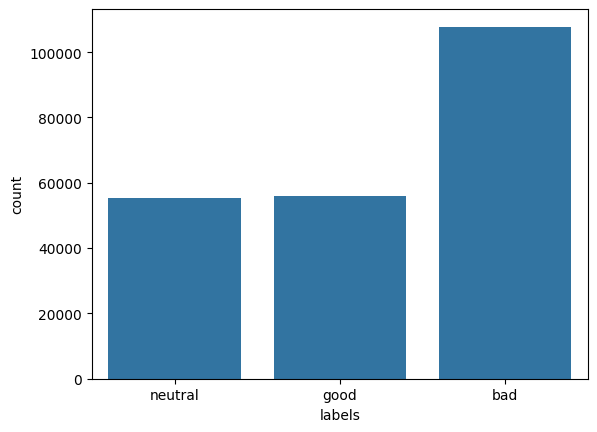

In [ ]:
# Let's observe distribution of positive / negative sentiments in dataset

import seaborn as sns
sns.countplot(x='labels', data=chatgpt_tweets)

**#Data Preprocessing**

In [ ]:
chatgpt_tweets["tweets"][5]

# You can see that our text contains punctuations, brackets, HTML tags and numbers
# We will preprocess this text in the next section

'Just launched ChatGPT, our new AI system which is optimized for dialogue: https://t.co/ArX6m0FfLE.\\n\\nTry it out here: https://t.co/YM1gp5bA64'

In [ ]:
TAG_RE = re.compile(r'<[^>]+>')

def remove_tags(text):
    '''Removes HTML tags: replaces anything between opening and closing <> with empty space'''

    return TAG_RE.sub('', text)

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
def preprocess_text(sen):
    '''Cleans text data up, leaving only 2 or more char long non-stepwords composed of A-Z & a-z only
    in lowercase'''

    sentence = sen.lower()

    # Remove html tags
    sentence = remove_tags(sentence)

    # Remove punctuations and numbers
    sentence = re.sub('[^a-zA-Z]', ' ', sentence)

    # Single character removal
    sentence = re.sub(r"\s+[a-zA-Z]\s+", ' ', sentence)  # When we remove apostrophe from the word "Mark's", the apostrophe is replaced by an empty space. Hence, we are left with single character "s" that we are removing here.

    # Remove multiple spaces
    sentence = re.sub(r'\s+', ' ', sentence)  # Next, we remove all the single characters and replace it by a space which creates multiple spaces in our text. Finally, we remove the multiple spaces from our text as well.

    # Remove Stopwords
    pattern = re.compile(r'\b(' + r'|'.join(stopwords.words('english')) + r')\b\s*')
    sentence = pattern.sub('', sentence)

    return sentence

In [ ]:
# Calling preprocessing_text function on movie_reviews

X = []
sentences = list(chatgpt_tweets['tweets'])
for sen in sentences:
    X.append(preprocess_text(sen))

In [ ]:
# Sample cleaned up movie review

X[5]

# Word Embeddings is going to be used,so stemming/lemmatization is not performed as a preprocessing

'launched chatgpt new ai system optimized dialogue https co arx ffle ntry https co ym gp ba '

In [ ]:
#converting sentiment strings to numerical labels
#sentiment_mapping = {'good':2, 'neutral':1, 'bad':0}
#chatgpt_tweets["labels"] = chatgpt_tweets["labels"].map(sentiment_mapping)
chatgpt_tweets['labels'] = chatgpt_tweets['labels'].map({'good':2, 'neutral':1, 'bad':0})

In [ ]:
print(chatgpt_tweets['labels'].unique())

[1 2 0]


In [ ]:
#converting labels to categorical (one-hot encoding)
y = to_categorical(chatgpt_tweets['labels'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# The train set to train the deep learning models
# test set to evaluate how well model performs

Preparing embedding layer

Embedding layer converts textual data into numerical form. Later it is used as the first layer for the deep learning models in keras.

In [ ]:
# Embedding layer expects the words to be in numeric form
# Using Tokenizer function from keras.preprocessing.text library
# Method fit_on_text trains the tokenizer
# Method texts_to_sequences converts sentences to their numeric form

word_tokenizer = Tokenizer()
word_tokenizer.fit_on_texts(X_train)

X_train = word_tokenizer.texts_to_sequences(X_train)
X_test = word_tokenizer.texts_to_sequences(X_test)

In [ ]:
# Adding 1 to store dimensions for words for which no pretrained word embeddings exist

vocab_length = len(word_tokenizer.word_index) + 1

vocab_length

219688

In [ ]:
# Padding all reviews to fixed length 100

maxlen = 100

X_train = pad_sequences(X_train, padding='post', maxlen=maxlen)
X_test = pad_sequences(X_test, padding='post', maxlen=maxlen)

In [ ]:
# Load GloVe word embeddings and create an Embeddings Dictionary

from numpy import asarray
from numpy import zeros

embeddings_dictionary = dict()
glove_file = open('a2_glove.6B.100d.txt', encoding="utf8")

for line in glove_file:
    records = line.split()
    word = records[0]
    vector_dimensions = asarray(records[1:], dtype='float32')
    embeddings_dictionary [word] = vector_dimensions
glove_file.close()

In [ ]:
# Create Embedding Matrix having 100 columns
# Containing 100-dimensional GloVe word embeddings for all words in our corpus.

embedding_matrix = zeros((vocab_length, 100))
for word, index in word_tokenizer.word_index.items():
    embedding_vector = embeddings_dictionary.get(word)
    if embedding_vector is not None:
        embedding_matrix[index] = embedding_vector

In [ ]:
embedding_matrix.shape

(219688, 100)

**Model Training with different Models**




**1. Convolutional Neural Network**

In [ ]:
from keras.layers import Conv1D

In [ ]:
# Neural Network architecture

cnn_model = Sequential()

embedding_layer = Embedding(vocab_length, 100, weights=[embedding_matrix], input_length=maxlen , trainable=False)
cnn_model.add(embedding_layer)

cnn_model.add(Conv1D(128, 5, activation='relu'))
cnn_model.add(GlobalMaxPooling1D())
#softmax instead of sigmoid for handling three classes
cnn_model.add(Dense(3, activation='softmax'))

In [ ]:
# Model compiling
#categorical_crossentropy as loss for handling multi-class classification

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
print(cnn_model.summary())

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 100, 100)          21968800  
                                                                 
 conv1d_1 (Conv1D)           (None, 96, 128)           64128     
                                                                 
 global_max_pooling1d_1 (Gl  (None, 128)               0         
 obalMaxPooling1D)                                               
                                                                 
 dense_2 (Dense)             (None, 3)                 387       
                                                                 
Total params: 22033315 (84.05 MB)
Trainable params: 64515 (252.01 KB)
Non-trainable params: 21968800 (83.80 MB)
_________________________________________________________________
None


In [ ]:
# Model training

cnn_model_history = cnn_model.fit(X_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

Epoch 1/6
1097/1097 [==============================] - 111s 101ms/step - loss: 0.7056 - acc: 0.6926 - val_loss: 0.6124 - val_acc: 0.7448
Epoch 2/6
1097/1097 [==============================] - 106s 97ms/step - loss: 0.5590 - acc: 0.7713 - val_loss: 0.5794 - val_acc: 0.7626
Epoch 3/6
1097/1097 [==============================] - 109s 99ms/step - loss: 0.4956 - acc: 0.8022 - val_loss: 0.5654 - val_acc: 0.7680
Epoch 4/6
1097/1097 [==============================] - 108s 98ms/step - loss: 0.4491 - acc: 0.8226 - val_loss: 0.5530 - val_acc: 0.7765
Epoch 5/6
1097/1097 [==============================] - 106s 97ms/step - loss: 0.4127 - acc: 0.8400 - val_loss: 0.5602 - val_acc: 0.7791
Epoch 6/6
1097/1097 [==============================] - 110s 101ms/step - loss: 0.3835 - acc: 0.8531 - val_loss: 0.5760 - val_acc: 0.7756


In [ ]:
#create prediction from X_test set and display classification report
#create confusion matrix for the X_test set
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

In [ ]:
y_pred  = cnn_model.predict(X_test)
#y_pred_classes = np.round(y_pred)
y_pred_classes = np.argmax(y_pred, axis=1)

#convert one-hot encoded test labels back to labels
y_test_classes = np.argmax(y_test, axis=1)

1371/1371 [==============================] - 15s 11ms/step


In [ ]:
# Convert predictions and true labels to binary (0 or 1)
#y_pred_classes = y_pred_classes.flatten()
#y_test = y_test.flatten()

In [ ]:
# Generate the classification report
print(classification_report(y_test_classes, y_pred_classes, target_names=['bad', 'neutral', 'good']))

#confusion matrix
print(confusion_matrix(y_test_classes, y_pred_classes))

              precision    recall  f1-score   support

         bad       0.83      0.90      0.86     21474
     neutral       0.64      0.53      0.58     11181
        good       0.77      0.77      0.77     11204

    accuracy                           0.77     43859
   macro avg       0.75      0.73      0.74     43859
weighted avg       0.77      0.77      0.77     43859

[[19424  1522   528]
 [ 3300  5878  2003]
 [  812  1718  8674]]


In [ ]:
# Predictions on the Test Set

score = cnn_model.evaluate(X_test, y_test, verbose=1)

1371/1371 [==============================] - 15s 11ms/step - loss: 0.5814 - acc: 0.7747


In [ ]:
# Model Performance

print("Test Score:", score[0])
print("Test Accuracy:", score[1])

Test Score: 0.5814241170883179
Test Accuracy: 0.7746642827987671


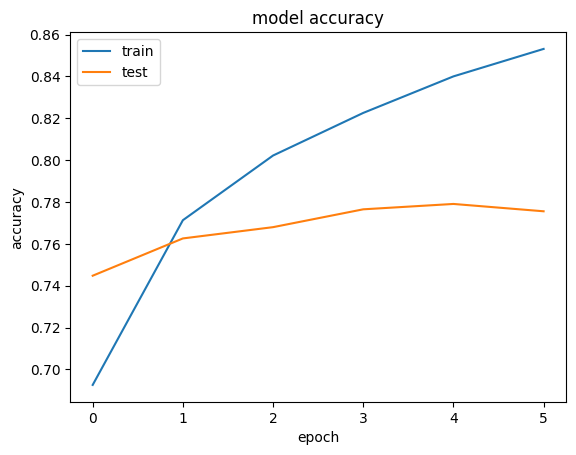

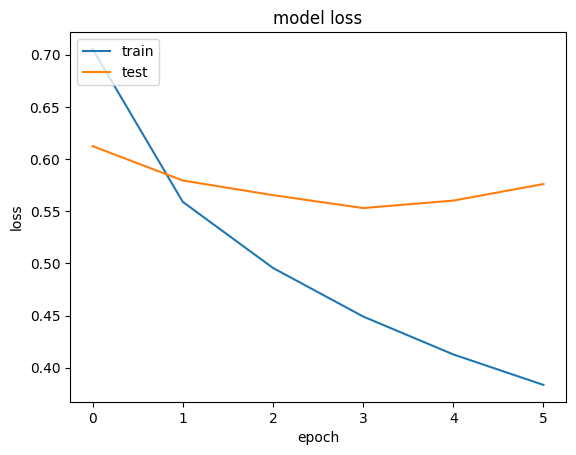

In [ ]:
# Model Performance Charts

import matplotlib.pyplot as plt

plt.plot(cnn_model_history.history['acc'])
plt.plot(cnn_model_history.history['val_acc'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc = 'upper left')
plt.show()

plt.plot(cnn_model_history.history['loss'])
plt.plot(cnn_model_history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc = 'upper left')
plt.show()

In [ ]:
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
import numpy as np

# Assuming you have a list of chat GPT tweets in 'chatgpt_tweets'
chatgpt_tweets = [
    "Chat GPT-3 is the latest language model released by OpenAI, a research lab dedicated to artificial intelligence. It is the world’s most powerful natural language processing (NLP) system and can generate human-like text for a wide range of applications.",
]

# Tokenize the text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(chatgpt_tweets)
sequences = tokenizer.texts_to_sequences(chatgpt_tweets)

# Pad the sequences to have the same length as your training data
max_sequence_length = 100  # Adjust based on your training data
X_new = pad_sequences(sequences, maxlen=max_sequence_length)

# Now X_new is ready to be used for predictions
predictions = cnn_model.predict(X_new)

# If your model outputs probabilities and it's binary classification (sigmoid activation in the last layer)
# you might want to threshold them
#binary_predictions = (predictions > 0.5).astype(int)

# Print the predictions
# print("Raw Predictions:")
# print(predictions)
# print("Binary Predictions (if applicable):")
# print(binary_predictions)

# threshold = 0.5
# binary_predictions = (predictions >= threshold).astype(int)

# For multi-class classification, find the index of the max probability
predicted_classes = np.argmax(predictions, axis=1)

# Print the sentiments
class_labels = {0: 'Bad', 1: 'Neutral', 2: 'Good'}

#Translate predictions to labels
predicted_labels = [class_labels[pred] for pred in predicted_classes]

# Print the reviews with their predicted sentiments
for review, predicted_label in zip(chatgpt_tweets, predicted_labels):
    print(f"Review: {review}\nPredicted Sentiment: {predicted_label}\n")


1/1 [==============================] - 0s 25ms/step
Review: Chat GPT-3 is the latest language model released by OpenAI, a research lab dedicated to artificial intelligence. It is the world’s most powerful natural language processing (NLP) system and can generate human-like text for a wide range of applications.
Predicted Sentiment: Good



**2. Recurrent Neural Network: LSTM**

In [ ]:
from keras.layers import LSTM

In [ ]:
# Neural Network architecture

lstm_model = Sequential()
embedding_layer = Embedding(vocab_length, 100, weights=[embedding_matrix], input_length=maxlen , trainable=False)

lstm_model.add(embedding_layer)
lstm_model.add(LSTM(128))

lstm_model.add(Dense(3, activation='softmax'))

In [ ]:
# Model compiling

lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
print(lstm_model.summary())

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, 100, 100)          21968800  
                                                                 
 lstm_1 (LSTM)               (None, 128)               117248    
                                                                 
 dense_3 (Dense)             (None, 3)                 387       
                                                                 
Total params: 22086435 (84.25 MB)
Trainable params: 117635 (459.51 KB)
Non-trainable params: 21968800 (83.80 MB)
_________________________________________________________________
None


In [ ]:
# Model Training

lstm_model_history = lstm_model.fit(X_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

Epoch 1/6
1097/1097 [==============================] - 358s 324ms/step - loss: 0.7537 - acc: 0.6595 - val_loss: 0.6318 - val_acc: 0.7276
Epoch 2/6
1097/1097 [==============================] - 350s 319ms/step - loss: 0.5911 - acc: 0.7538 - val_loss: 0.5736 - val_acc: 0.7583
Epoch 3/6
1097/1097 [==============================] - 351s 320ms/step - loss: 0.5044 - acc: 0.8022 - val_loss: 0.4718 - val_acc: 0.8192
Epoch 4/6
1097/1097 [==============================] - 363s 331ms/step - loss: 0.4830 - acc: 0.8136 - val_loss: 0.4705 - val_acc: 0.8228
Epoch 5/6
1097/1097 [==============================] - 351s 319ms/step - loss: 0.4222 - acc: 0.8425 - val_loss: 0.4161 - val_acc: 0.8428
Epoch 6/6
1097/1097 [==============================] - 351s 320ms/step - loss: 0.3866 - acc: 0.8577 - val_loss: 0.4393 - val_acc: 0.8302


In [ ]:
#prediction with LSTM model
y_pred  = lstm_model.predict(X_test)
#y_pred_classes = np.round(y_pred)
#convert predictions to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

#convert one-hot encoded test labels back to labels
y_test_classes = np.argmax(y_test, axis=1)

# Generate the classification report
print(classification_report(y_test_classes, y_pred_classes, target_names=['bad', 'neutral', 'good']))

#confusion matrix
print(confusion_matrix(y_test_classes, y_pred_classes))

1371/1371 [==============================] - 76s 55ms/step
              precision    recall  f1-score   support

         bad       0.85      0.95      0.90     21474
     neutral       0.71      0.67      0.69     11181
        good       0.91      0.75      0.82     11204

    accuracy                           0.83     43859
   macro avg       0.82      0.79      0.80     43859
weighted avg       0.83      0.83      0.83     43859

[[20457   869   148]
 [ 2986  7478   717]
 [  558  2229  8417]]


In [ ]:
 # Predictions on the Test Set

score = lstm_model.evaluate(X_test, y_test, verbose=1)

1371/1371 [==============================] - 73s 53ms/step - loss: 0.4487 - acc: 0.8288


In [ ]:
# Model Performance

print("Test Score:", score[0])
print("Test Accuracy:", score[1])

Test Score: 0.4487276077270508
Test Accuracy: 0.8288378715515137


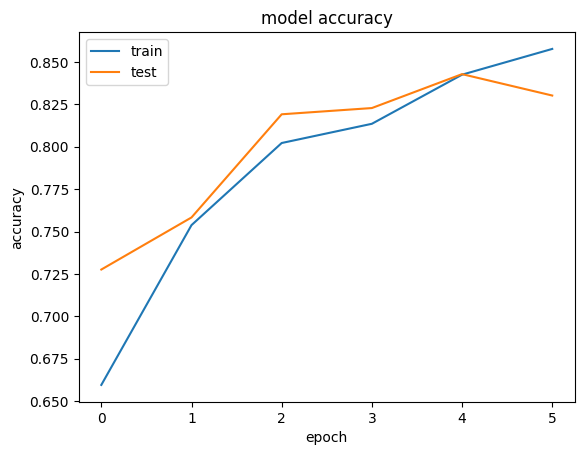

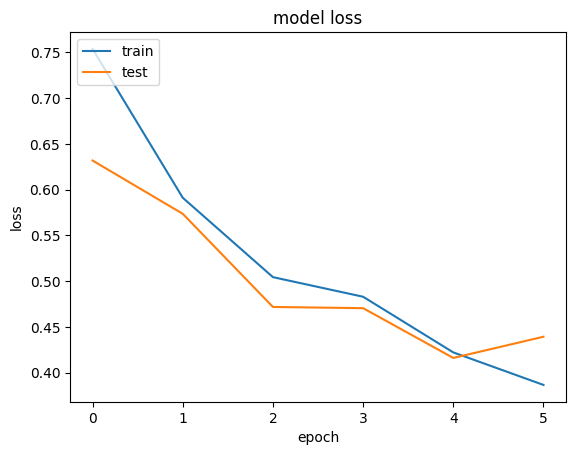

In [ ]:
# Model Performance Charts

import matplotlib.pyplot as plt

plt.plot(lstm_model_history.history['acc'])
plt.plot(lstm_model_history.history['val_acc'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(lstm_model_history.history['loss'])
plt.plot(lstm_model_history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

In [ ]:
# Saving the model as a h5 file for possible use later

lstm_model.save(f"./c1_lstm_model_acc_{round(score[1], 3)}.h5", save_format='h5')